In [1]:
print('Running imports...')
import os
from captum.attr import IntegratedGradients

os.environ["MKL_THREADING_LAYER"] = "GNU"

import torch # long
from lightning.pytorch import seed_everything
from torch import nn 

import xarray as xr
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import dask.bag as db
import argparse
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain')

from ml_module_rain.models.trained_models import load_trained_model


Running imports...


In [2]:
run_id = 'lozkymt2'

final_ds = xr.open_dataset(f"/Data/gfi/users/rogui7909/data/NN_outputs/attributions/{run_id}_attributions_extreme.nc")
final_ds['fields'] = final_ds.attributions/final_ds.sensitivity

In [3]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe().set_index('track_id').sort_index()
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True)
grid = xr.zeros_like(final_ds.attributions.isel(time_of_event=0, var_name=0, timestep=0, drop=True))

def get_cyclone_distance(date):
    pass

import numpy as np

def haversine_np(lon1, lat1, lon2, lat2, radius=6371):

    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return radius * c

In [4]:
date = '2001-10-29'

def get_distance_to_cyclone(date):
    date_min = (pd.to_datetime(date) - pd.Timedelta(3,'D')).strftime("%Y-%m-%d")
    features_date = df_features.loc[date].dropna().iloc[:-2]
    if features_date.size==0:
        # print("No feature")
        return
    cyclones_date = features_date.loc[features_date.str.startswith('C_')]
    if cyclones_date.size==0:
        # print("No cyclone")
        return
    cyclones_date = cyclones_date.str.split('_', expand=True).iloc[:,1].astype(int).values
    cycs_extract = cycs.loc[cyclones_date].set_index('date').sort_index()
    cycs_extract = cycs_extract.loc[date_min:date]
    cycs_extract = cycs_extract[['lon','lat']].to_xarray().rename(date='time')

    distance_to_cyclones = haversine_np(grid.longitude,grid.latitude, cycs_extract.lon, cycs_extract.lat)

    min_distances_to_cyclone = distance_to_cyclones.resample(time='D').min()
    min_distances_to_cyclone = min_distances_to_cyclone.assign_coords(time_of_event = pd.to_datetime(date))
    timesteps = (pd.to_datetime(min_distances_to_cyclone.time) - pd.to_datetime(date)).days
    min_distances_to_cyclone = min_distances_to_cyclone.rename(time='timestep').assign_coords(timestep=timesteps)
    return min_distances_to_cyclone

all_dist = []
days_str = final_ds.time_of_event.dt.strftime('%Y-%m-%d').values

for date in tqdm(days_str):
    dist = get_distance_to_cyclone(date)
    if dist is not None:
        all_dist.append(dist)
dist_to_cyclone = xr.concat(all_dist, dim='time_of_event')
final_ds['dist_to_cyclone'] = dist_to_cyclone
final_ds['distance_rank'] = final_ds.dist_to_cyclone.stack(space=['latitude','longitude']).rank('space', pct=True).unstack()

100%|██████████| 330/330 [00:11<00:00, 28.68it/s]


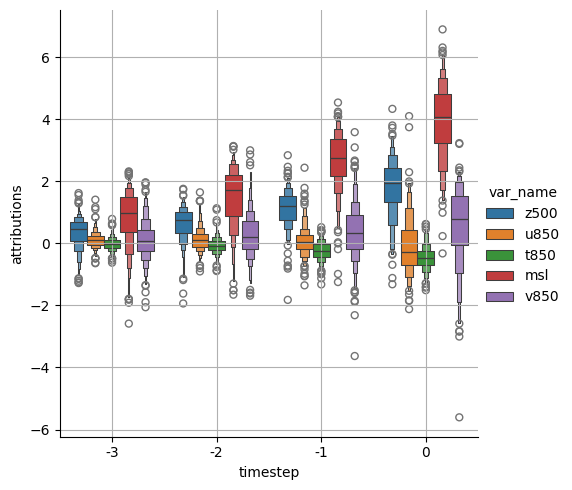

In [5]:
TP = final_ds.where(final_ds.prediction>0.8, drop=True)
df_ = TP.attributions.sum(['longitude','latitude'], min_count=1).to_series().reset_index()

sns.catplot(df_, x='timestep', y='attributions', hue='var_name',kind='boxen',)
plt.grid()

In [6]:
raw_data = xr.open_dataset("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr").sel(var_name='msl')
raw_data

<xarray.Dataset> Size: 8GB
Dimensions:      (time: 31047, latitude: 90, longitude: 360)
Coordinates:
  * longitude    (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
    var_name     <U5 20B 'msl'
  * time         (time) datetime64[ns] 248kB 1940-01-01 ... 2024-12-31
  * latitude     (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0
Data variables:
    data_normed  (time, latitude, longitude) float64 8GB ...
    mean_value   (latitude, longitude) float64 259kB ...
    std_value    float64 8B ...

In [30]:
attrs = final_ds.attributions
msl = final_ds.fields.sel(var_name='msl')*raw_data.std_value + raw_data.mean_value
from xarrayutils import xr_linregress
ds_2 = xr.Dataset(dict(attributions=attrs, msl=msl))
df__ = ds_2.to_dataframe().reset_index()
df__['msl_bin'] = pd.cut(df__.msl/100, np.arange(940,1070,10))

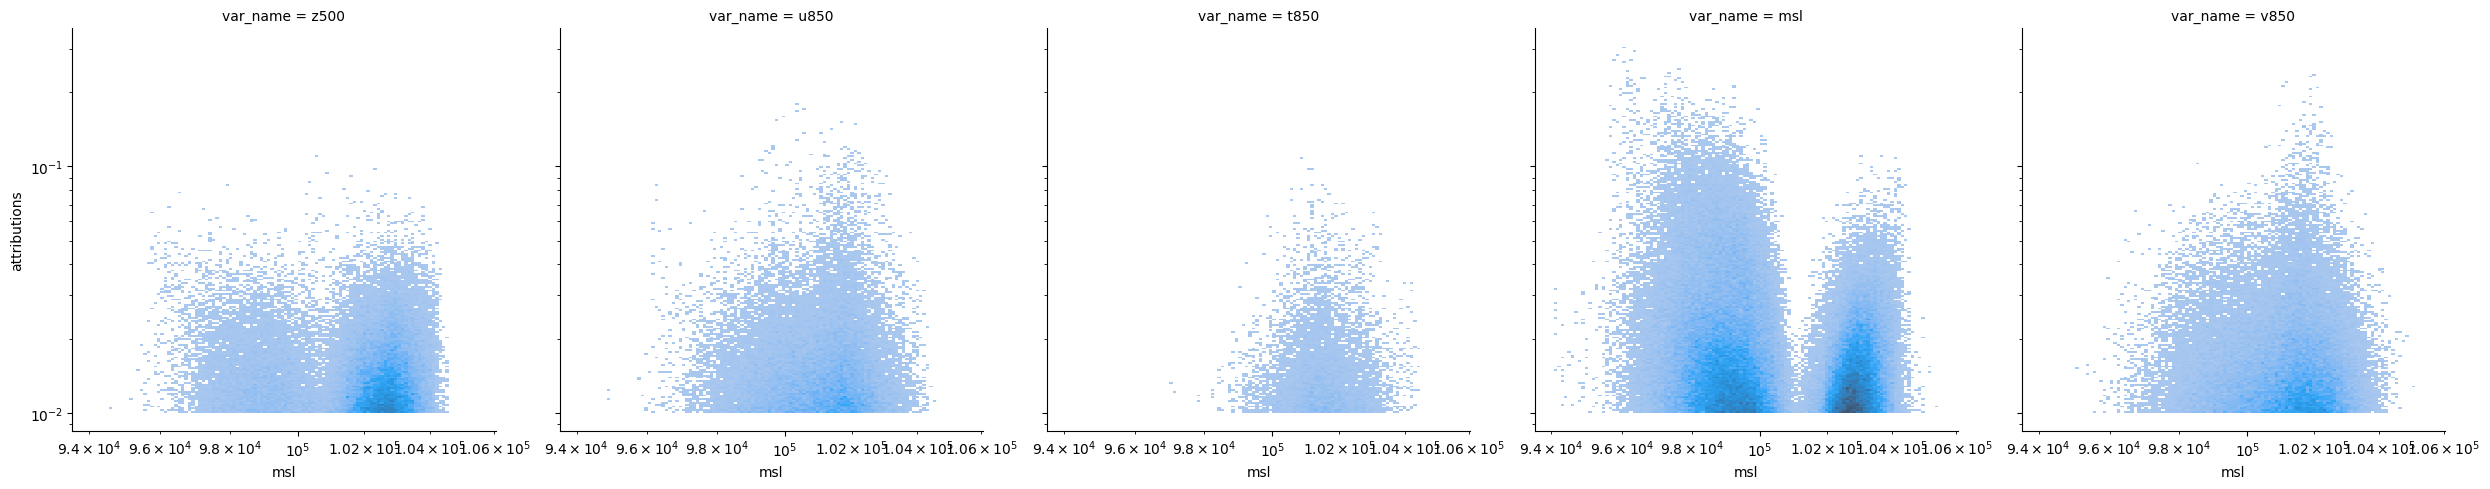

In [31]:
sns.displot(df__.loc[np.abs(df__.attributions)>0.01], x='msl', y='attributions', log_scale=True, col='var_name')


/tmp/ipykernel_2957406/1725187987.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df__.groupby(pd.cut(df__.msl/100, np.arange(940,1070,1))).attrs.sum().plot.bar()


<Axes: xlabel='msl'>

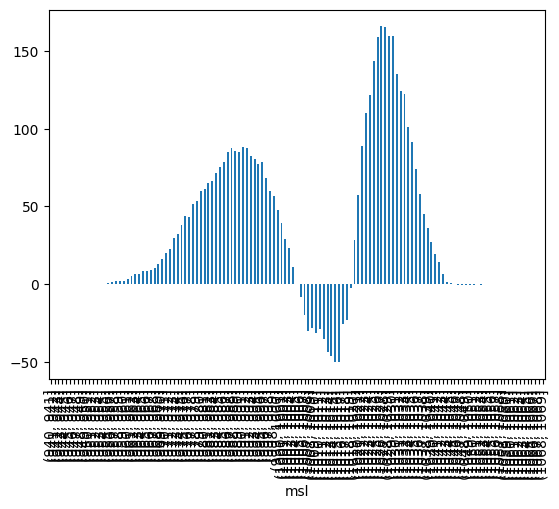

In [50]:
df__.groupby(pd.cut(df__.msl/100, np.arange(940,1070,1))).attrs.sum().plot.bar()